# 07 — Robot Portfolio Risk Analysis

Final sinyal ve çıkış kuralları artık sabittir:

- Buy score: 11
- Minimum ADX: 20
- Volume multiplier: 1.30
- Initial stop: 1.5 ATR
- Trailing stop: 2.5 ATR
- Trailing activation: %6

Bu notebook yalnızca portföy seviyesindeki kararları test eder:

- İşlem başına risk
- Maksimum açık pozisyon
- Tek hisse için maksimum portföy payı

Parametre seçimi Development ve Validation dönemleriyle yapılır.
Holdout sonuçları artık görüldüğü için portföy seçimine dahil edilmez.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = (
    Path.cwd()
    if (Path.cwd() / "src").exists()
    else Path.cwd().parent
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

from src.config import StrategyConfig, PortfolioConfig
from src.features import add_indicators
from src.signals import build_market_regime
from src.portfolio_experiments import (
    run_portfolio_grid,
    compare_portfolio_periods,
)

sns.set_theme(style="whitegrid")


c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Verileri ve final stratejiyi hazırla


In [2]:
stock_prices = pd.read_parquet(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "bist100_robot_clean.parquet"
)

market_prices = pd.read_parquet(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "xu100_robot_clean.parquet"
)

stock_features = add_indicators(stock_prices)
market_features = add_indicators(market_prices)
market_regime = build_market_regime(market_features)

PERIODS = {
    "Development": ("2018-01-01", "2022-12-31"),
    "Validation": ("2023-01-01", "2024-12-31"),
}

final_strategy = StrategyConfig(
    buy_score=12,
    minimum_adx=18.0,
    volume_multiplier=1.3,
    initial_stop_atr=2.0,
    trailing_stop_atr=2.5,
    trailing_activation_return=0.06,
)

base_portfolio = PortfolioConfig(
    initial_capital=500_000.0,
    commission_rate=0.002,
    slippage_rate=0.002,
)

print("Özellikli hisse verisi:", stock_features.shape)
print(
    "Tarih aralığı:",
    stock_features["Date"].min(),
    "→",
    stock_features["Date"].max(),
)


Özellikli hisse verisi: (152459, 42)
Tarih aralığı: 2018-10-18 00:00:00 → 2026-07-24 00:00:00


## 2. Development portföy grid'i

Toplam 27 kombinasyon:

- Risk per trade: %0,30 / %0,50 / %0,75
- Max positions: 6 / 8 / 10
- Tek hisse cap: sınırsız / %15 / %20

`max_position_fraction=None`, mevcut Robot pozisyon büyüklüğü davranışını korur.


In [3]:
portfolio_grid = {
    "risk_per_trade": [0.003, 0.005, 0.0075],
    "max_positions": [6, 8, 10],
    "max_position_fraction": [None, 0.15, 0.20],
}

portfolio_development = run_portfolio_grid(
    stock_features=stock_features,
    market_regime=market_regime,
    strategy_config=final_strategy,
    base_portfolio=base_portfolio,
    parameter_grid=portfolio_grid,
    start=PERIODS["Development"][0],
    end=PERIODS["Development"][1],
)

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

portfolio_development.to_csv(
    RESULTS_DIR / "portfolio_grid_development.csv",
    index=False,
)

print("Deney sayısı:", len(portfolio_development))
print(
    "Hata alan deney:",
    portfolio_development["Status"].ne("OK").sum(),
)


Portföy grid: 2018-01-01 → 2022-12-31: 100%|██████████| 27/27 [03:23<00:00,  7.54s/it]

Deney sayısı: 27
Hata alan deney: 0


## 3. Development dayanıklılık filtresi


In [4]:
development_candidates = (
    portfolio_development.loc[
        portfolio_development["Status"].eq("OK")
        & portfolio_development["Trade_Count"].ge(150)
        & portfolio_development["Profit_Factor"].ge(1.40)
        & portfolio_development["Max_Drawdown_%"].ge(-40.0)
    ]
    .sort_values(
        [
            "Calmar",
            "Sharpe",
            "Profit_Factor",
            "CAGR_%",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

portfolio_columns = [
    "Experiment_ID",
    "Portfolio_risk_per_trade",
    "Portfolio_max_positions",
    "Portfolio_max_position_fraction",
    "CAGR_%",
    "Max_Drawdown_%",
    "Profit_Factor",
    "Sharpe",
    "Calmar",
    "Trade_Count",
    "Exposure_%",
    "Average_Open_Positions",
    "Max_Open_Positions",
    "Average_Invested_%",
]

display(
    development_candidates[
        portfolio_columns
    ].head(15)
)


,Experiment_ID,Portfolio_risk_per_trade,Portfolio_max_positions,Portfolio_max_position_fraction,CAGR_%,Max_Drawdown_%,Profit_Factor,Sharpe,Calmar,Trade_Count,Exposure_%,Average_Open_Positions,Max_Open_Positions,Average_Invested_%
0,24,0.0075,8,0.20,60.996674,-21.036962,2.639109,2.580793,2.899500,396,95.351044,6.845351,8,66.022043
1,22,0.0075,8,NaN,60.984835,-21.036353,2.639109,2.580370,2.899021,396,95.351044,6.845351,8,66.030119
2,23,0.0075,8,0.15,60.761512,-21.182637,2.639109,2.575660,2.868458,396,95.351044,6.845351,8,65.901677
3,25,0.0075,10,NaN,71.696870,-25.934615,2.560221,2.619470,2.764524,486,94.781784,8.326376,10,75.669684
4,27,0.0075,10,0.20,70.841249,-25.934227,2.562466,2.595286,2.731574,485,94.781784,8.350095,10,75.792892
5,13,0.0050,8,NaN,39.611390,-14.566080,2.639109,2.590901,2.719427,396,95.351044,6.845351,8,45.404487
6,14,0.0050,8,0.15,39.611390,-14.566080,2.639109,2.590901,2.719427,396,95.351044,6.845351,8,45.404487
7,15,0.0050,8,0.20,39.611390,-14.566080,2.639109,2.590901,2.719427,396,95.351044,6.845351,8,45.404487
8,26,0.0075,10,0.15,69.991106,-26.786172,2.562091,2.566662,2.612957,486,94.781784,8.345351,10,75.492937
9,16,0.0050,10,NaN,47.007193,-18.520137,2.567697,2.574984,2.538167,485,94.781784,8.351044,10,55.004400


## 4. Mevcut portföy ayarını da Validation'a taşı

Mevcut ayar:

- Risk: %0,75
- Maksimum pozisyon: 8
- Tek hisse cap: yok


In [5]:
baseline_mask = (
    portfolio_development[
        "Portfolio_risk_per_trade"
    ].eq(0.0075)
    & portfolio_development[
        "Portfolio_max_positions"
    ].eq(8)
    & portfolio_development[
        "Portfolio_max_position_fraction"
    ].isna()
)

baseline_portfolio_row = portfolio_development.loc[
    baseline_mask
].copy()

selected_portfolios = (
    pd.concat(
        [
            development_candidates.head(10),
            baseline_portfolio_row,
        ],
        ignore_index=True,
    )
    .drop_duplicates(
        subset=[
            "Portfolio_risk_per_trade",
            "Portfolio_max_positions",
            "Portfolio_max_position_fraction",
        ]
    )
    .reset_index(drop=True)
)

parameter_columns = [
    "Portfolio_risk_per_trade",
    "Portfolio_max_positions",
    "Portfolio_max_position_fraction",
]

portfolio_comparison = compare_portfolio_periods(
    stock_features=stock_features,
    market_regime=market_regime,
    configurations=selected_portfolios,
    strategy_config=final_strategy,
    base_portfolio=base_portfolio,
    periods=PERIODS,
    parameter_columns=parameter_columns,
)

portfolio_comparison.to_csv(
    RESULTS_DIR / "portfolio_selected_validation.csv",
    index=False,
)

comparison_columns = [
    "Selected_Config",
    "Period_Name",
    "Portfolio_risk_per_trade",
    "Portfolio_max_positions",
    "Portfolio_max_position_fraction",
    "CAGR_%",
    "Max_Drawdown_%",
    "Profit_Factor",
    "Sharpe",
    "Calmar",
    "Trade_Count",
    "Exposure_%",
    "Average_Open_Positions",
    "Average_Invested_%",
]

display(
    portfolio_comparison[
        comparison_columns
    ].sort_values(
        ["Selected_Config", "Period_Name"]
    )
)


,Selected_Config,Period_Name,Portfolio_risk_per_trade,Portfolio_max_positions,Portfolio_max_position_fraction,CAGR_%,Max_Drawdown_%,Profit_Factor,Sharpe,Calmar,Trade_Count,Exposure_%,Average_Open_Positions,Average_Invested_%
0,1,Development,0.0075,8,0.20,60.996674,-21.036962,2.639109,2.580793,2.899500,396,95.351044,6.845351,66.022043
1,1,Validation,0.0075,8,0.20,27.310294,-18.310984,1.626837,1.385437,1.491471,215,98.995984,7.168675,62.266399
2,2,Development,0.0075,8,NaN,60.984835,-21.036353,2.639109,2.580370,2.899021,396,95.351044,6.845351,66.030119
3,2,Validation,0.0075,8,NaN,27.310294,-18.310984,1.626837,1.385437,1.491471,215,98.995984,7.168675,62.266399
4,3,Development,0.0075,8,0.15,60.761512,-21.182637,2.639109,2.575660,2.868458,396,95.351044,6.845351,65.901677
5,3,Validation,0.0075,8,0.15,27.310294,-18.310984,1.626837,1.385437,1.491471,215,98.995984,7.168675,62.266399
6,4,Development,0.0075,10,NaN,71.696870,-25.934615,2.560221,2.619470,2.764524,486,94.781784,8.326376,75.669684
7,4,Validation,0.0075,10,NaN,41.169230,-25.023853,1.753893,1.650900,1.645200,270,99.397590,8.859438,75.232809
8,5,Development,0.0075,10,0.20,70.841249,-25.934227,2.562466,2.595286,2.731574,485,94.781784,8.350095,75.792892
9,5,Validation,0.0075,10,0.20,41.169230,-25.023853,1.753893,1.650900,1.645200,270,99.397590,8.859438,75.232809


## 5. Development–Validation istikrar tablosu


In [6]:
portfolio_comparison["Position_Cap_Label"] = (
    portfolio_comparison[
        "Portfolio_max_position_fraction"
    ]
    .map(
        lambda value: (
            "None"
            if pd.isna(value)
            else f"{value:.2f}"
        )
    )
)

portfolio_stability = portfolio_comparison.pivot_table(
    index=[
        "Selected_Config",
        "Portfolio_risk_per_trade",
        "Portfolio_max_positions",
        "Position_Cap_Label",
    ],
    columns="Period_Name",
    values=[
        "CAGR_%",
        "Max_Drawdown_%",
        "Profit_Factor",
        "Sharpe",
        "Calmar",
        "Trade_Count",
        "Exposure_%",
        "Average_Open_Positions",
        "Average_Invested_%",
    ],
    aggfunc="first",
)

portfolio_stability.columns = [
    f"{metric}_{period}"
    for metric, period in portfolio_stability.columns
]

portfolio_stability = portfolio_stability.reset_index()

portfolio_stability["Robust_Calmar"] = portfolio_stability[
    ["Calmar_Development", "Calmar_Validation"]
].min(axis=1)

portfolio_stability["Robust_PF"] = portfolio_stability[
    [
        "Profit_Factor_Development",
        "Profit_Factor_Validation",
    ]
].min(axis=1)

portfolio_stability["Robust_Sharpe"] = portfolio_stability[
    ["Sharpe_Development", "Sharpe_Validation"]
].min(axis=1)

portfolio_stability["Worst_Drawdown"] = portfolio_stability[
    [
        "Max_Drawdown_%_Development",
        "Max_Drawdown_%_Validation",
    ]
].min(axis=1)

portfolio_stability["CAGR_Gap"] = (
    portfolio_stability["CAGR_%_Development"]
    - portfolio_stability["CAGR_%_Validation"]
).abs()

portfolio_stability = portfolio_stability.sort_values(
    [
        "Robust_Calmar",
        "Robust_PF",
        "Robust_Sharpe",
        "CAGR_Gap",
    ],
    ascending=[False, False, False, True],
).reset_index(drop=True)

display(portfolio_stability)


,Selected_Config,Portfolio_risk_per_trade,Portfolio_max_positions,Position_Cap_Label,Average_Invested_%_Development,Average_Invested_%_Validation,Average_Open_Positions_Development,Average_Open_Positions_Validation,CAGR_%_Development,CAGR_%_Validation,...,Profit_Factor_Validation,Sharpe_Development,Sharpe_Validation,Trade_Count_Development,Trade_Count_Validation,Robust_Calmar,Robust_PF,Robust_Sharpe,Worst_Drawdown,CAGR_Gap
0,9,0.0075,10,0.15,75.492937,75.232809,8.345351,8.859438,69.991106,41.169230,...,1.753893,2.566662,1.650900,486,270,1.645200,1.753893,1.650900,-26.786172,28.821876
1,5,0.0075,10,0.20,75.792892,75.232809,8.350095,8.859438,70.841249,41.169230,...,1.753893,2.595286,1.650900,485,270,1.645200,1.753893,1.650900,-25.934227,29.672019
2,4,0.0075,10,None,75.669684,75.232809,8.326376,8.859438,71.696870,41.169230,...,1.753893,2.619470,1.650900,486,270,1.645200,1.753893,1.650900,-25.934615,30.527639
3,10,0.0050,10,None,55.004400,51.416928,8.351044,8.859438,47.007193,27.659821,...,1.753893,2.574984,1.678095,485,270,1.615445,1.753893,1.678095,-18.520137,19.347372
4,6,0.0050,8,None,45.404487,42.186156,6.845351,7.168675,39.611390,18.602329,...,1.626837,2.590901,1.415746,396,215,1.501734,1.626837,1.415746,-14.566080,21.009062
5,7,0.0050,8,0.15,45.404487,42.186156,6.845351,7.168675,39.611390,18.602329,...,1.626837,2.590901,1.415746,396,215,1.501734,1.626837,1.415746,-14.566080,21.009062
6,8,0.0050,8,0.20,45.404487,42.186156,6.845351,7.168675,39.611390,18.602329,...,1.626837,2.590901,1.415746,396,215,1.501734,1.626837,1.415746,-14.566080,21.009062
7,3,0.0075,8,0.15,65.901677,62.266399,6.845351,7.168675,60.761512,27.310294,...,1.626837,2.575660,1.385437,396,215,1.491471,1.626837,1.385437,-21.182637,33.451218
8,2,0.0075,8,None,66.030119,62.266399,6.845351,7.168675,60.984835,27.310294,...,1.626837,2.580370,1.385437,396,215,1.491471,1.626837,1.385437,-21.036353,33.674540
9,1,0.0075,8,0.20,66.022043,62.266399,6.845351,7.168675,60.996674,27.310294,...,1.626837,2.580793,1.385437,396,215,1.491471,1.626837,1.385437,-21.036962,33.686380


## 6. Risk profillerine göre kısa liste

- Conservative: iki dönemde de drawdown en kötü %20
- Balanced: iki dönemde de drawdown en kötü %25
- Aggressive: iki dönemde de drawdown en kötü %32

Her grupta Validation Profit Factor en az 1,40 olmalıdır.


In [7]:
def risk_bucket(
    df: pd.DataFrame,
    drawdown_floor: float,
) -> pd.DataFrame:
    return (
        df.loc[
            df["Worst_Drawdown"].ge(drawdown_floor)
            & df["Profit_Factor_Validation"].ge(1.40)
            & df["CAGR_%_Validation"].gt(0)
        ]
        .sort_values(
            [
                "Robust_Calmar",
                "Robust_PF",
                "CAGR_Gap",
            ],
            ascending=[False, False, True],
        )
        .head(5)
    )

conservative = risk_bucket(
    portfolio_stability,
    drawdown_floor=-20.0,
)

balanced = risk_bucket(
    portfolio_stability,
    drawdown_floor=-25.0,
)

aggressive = risk_bucket(
    portfolio_stability,
    drawdown_floor=-32.0,
)

print("CONSERVATIVE")
display(conservative)

print("BALANCED")
display(balanced)

print("AGGRESSIVE")
display(aggressive)


CONSERVATIVE


,Selected_Config,Portfolio_risk_per_trade,Portfolio_max_positions,Position_Cap_Label,Average_Invested_%_Development,Average_Invested_%_Validation,Average_Open_Positions_Development,Average_Open_Positions_Validation,CAGR_%_Development,CAGR_%_Validation,...,Profit_Factor_Validation,Sharpe_Development,Sharpe_Validation,Trade_Count_Development,Trade_Count_Validation,Robust_Calmar,Robust_PF,Robust_Sharpe,Worst_Drawdown,CAGR_Gap
3,10,0.005,10,None,55.004400,51.416928,8.351044,8.859438,47.007193,27.659821,...,1.753893,2.574984,1.678095,485,270,1.615445,1.753893,1.678095,-18.520137,19.347372
4,6,0.005,8,None,45.404487,42.186156,6.845351,7.168675,39.611390,18.602329,...,1.626837,2.590901,1.415746,396,215,1.501734,1.626837,1.415746,-14.566080,21.009062
5,7,0.005,8,0.15,45.404487,42.186156,6.845351,7.168675,39.611390,18.602329,...,1.626837,2.590901,1.415746,396,215,1.501734,1.626837,1.415746,-14.566080,21.009062
6,8,0.005,8,0.20,45.404487,42.186156,6.845351,7.168675,39.611390,18.602329,...,1.626837,2.590901,1.415746,396,215,1.501734,1.626837,1.415746,-14.566080,21.009062


BALANCED


,Selected_Config,Portfolio_risk_per_trade,Portfolio_max_positions,Position_Cap_Label,Average_Invested_%_Development,Average_Invested_%_Validation,Average_Open_Positions_Development,Average_Open_Positions_Validation,CAGR_%_Development,CAGR_%_Validation,...,Profit_Factor_Validation,Sharpe_Development,Sharpe_Validation,Trade_Count_Development,Trade_Count_Validation,Robust_Calmar,Robust_PF,Robust_Sharpe,Worst_Drawdown,CAGR_Gap
3,10,0.0050,10,None,55.004400,51.416928,8.351044,8.859438,47.007193,27.659821,...,1.753893,2.574984,1.678095,485,270,1.615445,1.753893,1.678095,-18.520137,19.347372
4,6,0.0050,8,None,45.404487,42.186156,6.845351,7.168675,39.611390,18.602329,...,1.626837,2.590901,1.415746,396,215,1.501734,1.626837,1.415746,-14.566080,21.009062
5,7,0.0050,8,0.15,45.404487,42.186156,6.845351,7.168675,39.611390,18.602329,...,1.626837,2.590901,1.415746,396,215,1.501734,1.626837,1.415746,-14.566080,21.009062
6,8,0.0050,8,0.20,45.404487,42.186156,6.845351,7.168675,39.611390,18.602329,...,1.626837,2.590901,1.415746,396,215,1.501734,1.626837,1.415746,-14.566080,21.009062
7,3,0.0075,8,0.15,65.901677,62.266399,6.845351,7.168675,60.761512,27.310294,...,1.626837,2.575660,1.385437,396,215,1.491471,1.626837,1.385437,-21.182637,33.451218


AGGRESSIVE


,Selected_Config,Portfolio_risk_per_trade,Portfolio_max_positions,Position_Cap_Label,Average_Invested_%_Development,Average_Invested_%_Validation,Average_Open_Positions_Development,Average_Open_Positions_Validation,CAGR_%_Development,CAGR_%_Validation,...,Profit_Factor_Validation,Sharpe_Development,Sharpe_Validation,Trade_Count_Development,Trade_Count_Validation,Robust_Calmar,Robust_PF,Robust_Sharpe,Worst_Drawdown,CAGR_Gap
0,9,0.0075,10,0.15,75.492937,75.232809,8.345351,8.859438,69.991106,41.169230,...,1.753893,2.566662,1.650900,486,270,1.645200,1.753893,1.650900,-26.786172,28.821876
1,5,0.0075,10,0.20,75.792892,75.232809,8.350095,8.859438,70.841249,41.169230,...,1.753893,2.595286,1.650900,485,270,1.645200,1.753893,1.650900,-25.934227,29.672019
2,4,0.0075,10,None,75.669684,75.232809,8.326376,8.859438,71.696870,41.169230,...,1.753893,2.619470,1.650900,486,270,1.645200,1.753893,1.650900,-25.934615,30.527639
3,10,0.0050,10,None,55.004400,51.416928,8.351044,8.859438,47.007193,27.659821,...,1.753893,2.574984,1.678095,485,270,1.615445,1.753893,1.678095,-18.520137,19.347372
4,6,0.0050,8,None,45.404487,42.186156,6.845351,7.168675,39.611390,18.602329,...,1.626837,2.590901,1.415746,396,215,1.501734,1.626837,1.415746,-14.566080,21.009062


## 7. Risk–getiri grafiği


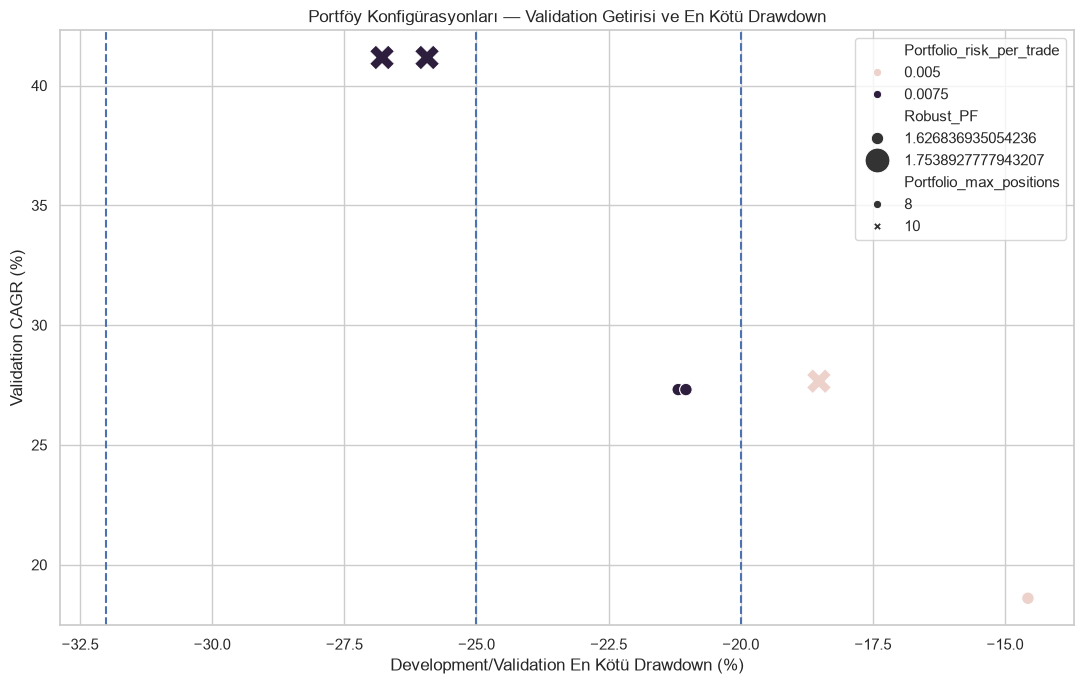

In [8]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=portfolio_stability,
    x="Worst_Drawdown",
    y="CAGR_%_Validation",
    size="Robust_PF",
    hue="Portfolio_risk_per_trade",
    style="Portfolio_max_positions",
    sizes=(80, 320),
)

plt.axvline(-20, linestyle="--")
plt.axvline(-25, linestyle="--")
plt.axvline(-32, linestyle="--")

plt.title(
    "Portföy Konfigürasyonları — "
    "Validation Getirisi ve En Kötü Drawdown"
)
plt.xlabel(
    "Development/Validation En Kötü Drawdown (%)"
)
plt.ylabel("Validation CAGR (%)")
plt.tight_layout()
plt.show()


## 8. Sonuçları kaydet

Final seçim ilkesi:

1. Önce gerçek hayatta kabul edilebilir drawdown sınırını belirle.
2. O sınır içindeki en yüksek Robust Calmar sonucunu seç.
3. Validation Profit Factor'ın en az 1,40 kalmasını iste.
4. Tek hisse cap kullanılan ve kullanılmayan sonuçları karşılaştır.
5. Seçimden sonra yeni parametre araması yapmadan paper trading'e geç.


In [9]:
portfolio_stability.to_csv(
    RESULTS_DIR / "portfolio_stability.csv",
    index=False,
)

conservative.to_csv(
    RESULTS_DIR / "portfolio_conservative.csv",
    index=False,
)

balanced.to_csv(
    RESULTS_DIR / "portfolio_balanced.csv",
    index=False,
)

aggressive.to_csv(
    RESULTS_DIR / "portfolio_aggressive.csv",
    index=False,
)

print("Portföy risk analizi sonuçları kaydedildi.")


Portföy risk analizi sonuçları kaydedildi.
